# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

**Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Imagine poder prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

**Objetivo**

Queremos desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, vamos usar uma base de dados que contém informações detalhadas sobre os clientes, incluindo:

Dados demográficos (idade, renda, etc.)

Informações sobre compras anteriores



# Base de dados:

Year_Birth: Ano de nascimento do cliente.

Education: Nível de escolaridade do cliente.

Marital_Status: Estado civil do cliente.

Income: Renda anual da família do cliente.

Kidhome: Número de crianças na casa do cliente.

Recency: Número de dias desde a última compra do cliente.

Complain: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.

MntWines: Valor gasto em vinhos nos últimos 2 anos.

MntFruits: Valor gasto em frutas nos últimos 2 anos.

MntMeatProducts: Valor gasto em carnes nos últimos 2 anos.

MntFishProducts: Valor gasto em peixes nos últimos 2 anos.

MntSweetProducts: Valor gasto em doces nos últimos 2 anos.

MntGoldProds: Valor gasto em produtos de ouro nos últimos 2 anos.

NumDealsPurchases: Número de compras feitas com desconto

NumStorePurchases: Número de compras feitas diretamente nas lojas.

NumWebVisitsMonth: Número de visitas ao site da empresa no último mês.






**WebPurchases: Número de compras feitas pelo site da empresa.**

# ETAPA 1:

**Preparação dos Dados**

**Exploração e Limpeza:** Analisar e limpar os dados para garantir que estejam prontos para a modelagem.

**Análise:** Construa uma storytelling com gráficos, analisando e retirando insights das informações.

In [94]:
#Importação das bibliotecas necessárias para o código
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier

In [95]:
#Carregamento da base com chunks
chunks = pd.read_csv('marketing_campaign.csv', chunksize=5000, sep=';')
df = pd.concat(chunks, ignore_index=True)

print(df.shape)  # Veja o tamanho do DataFrame carregado

(2240, 16)


Foi necessário utilizar esse métodos de chunks para partir a base pois o jupyter não estava conseguindo carregar a base inteira.

In [96]:
df

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,46,709,43,182,42,118,247,4,5,0,1
2236,1946,PhD,Together,64014.0,2,56,406,0,30,0,0,8,5,7,0,1
2237,1981,Graduation,Divorced,56981.0,0,91,908,48,217,32,12,24,13,6,0,0
2238,1956,Master,Together,69245.0,0,8,428,30,214,80,30,61,10,3,0,1


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   str    
 2   Marital_Status     2240 non-null   str    
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int64  
dtypes: float64(1), int64(13), str(2)
me

In [97]:
#Verificação de dados ausentes
(df.isnull().sum()) / len(df) * 100

Year_Birth           0.000000
Education            0.000000
Marital_Status       0.000000
Income               1.071429
Kidhome              0.000000
Recency              0.000000
MntWines             0.000000
MntFruits            0.000000
MntMeatProducts      0.000000
MntFishProducts      0.000000
MntSweetProducts     0.000000
MntGoldProds         0.000000
NumStorePurchases    0.000000
NumWebVisitsMonth    0.000000
Complain             0.000000
WebPurchases         0.000000
dtype: float64

In [53]:
#Observando o padrão dos dados ausentes
df[df['Income'].isna()]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
10,1983,Graduation,Married,NaN,1,11,5,5,6,0,2,1,2,7,0,0
27,1986,Graduation,Single,NaN,1,19,5,1,3,3,263,362,0,1,0,1
43,1959,PhD,Single,NaN,0,80,81,11,50,3,2,39,4,2,0,0
48,1951,Graduation,Single,NaN,2,96,48,5,48,6,10,7,4,6,0,0
58,1982,Graduation,Single,NaN,1,57,11,3,22,2,2,6,3,6,0,0
71,1973,2n Cycle,Married,NaN,1,25,25,3,43,17,4,17,3,8,0,0
90,1957,PhD,Married,NaN,2,4,230,42,192,49,37,53,8,9,0,1
91,1957,Graduation,Single,NaN,1,45,7,0,8,2,0,1,2,7,0,0
92,1973,Master,Together,NaN,0,87,445,37,359,98,28,18,8,1,0,0
128,1961,PhD,Married,NaN,0,23,352,0,27,10,0,15,7,6,0,1


A porcentagem de dados ausentes é bem baixa para o coluna Income com 1%, e não aparenta ter algum padrão específico, portanto optou-se por excluir os dados ausentes.

In [54]:
df.groupby(df['Income'].isna()).mean(numeric_only=True)

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
Income,,,,,,,,,,,,,,
False,1968.820397,52247.251354,0.441787,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,5.800993,5.319043,0.009477,0.504513
True,1967.458333,NaN,0.666667,58.041667,197.208333,21.333333,162.708333,27.166667,30.208333,49.250000,4.791667,5.083333,0.000000,0.416667


In [98]:
df = df.dropna()

In [99]:
(df.isnull().sum()) / len(df) * 100

Year_Birth           0.0
Education            0.0
Marital_Status       0.0
Income               0.0
Kidhome              0.0
Recency              0.0
MntWines             0.0
MntFruits            0.0
MntMeatProducts      0.0
MntFishProducts      0.0
MntSweetProducts     0.0
MntGoldProds         0.0
NumStorePurchases    0.0
NumWebVisitsMonth    0.0
Complain             0.0
WebPurchases         0.0
dtype: float64

In [15]:
#Verificação da distribuição dos dados
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,1968.820397,52247.251354,0.441787,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,5.800993,5.319043,0.009477,0.504513
std,11.985554,25173.076661,0.536896,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,3.250785,2.425359,0.096907,0.500092
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68522.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,13.000000,20.000000,1.000000,1.000000


Income pode ter outlier. Recency. MntWines. MntFruits. MntMeatProducts. MntFishProducts. MntSweetProducts. NumStorePurchases.  NumWebVisitsMonth. 

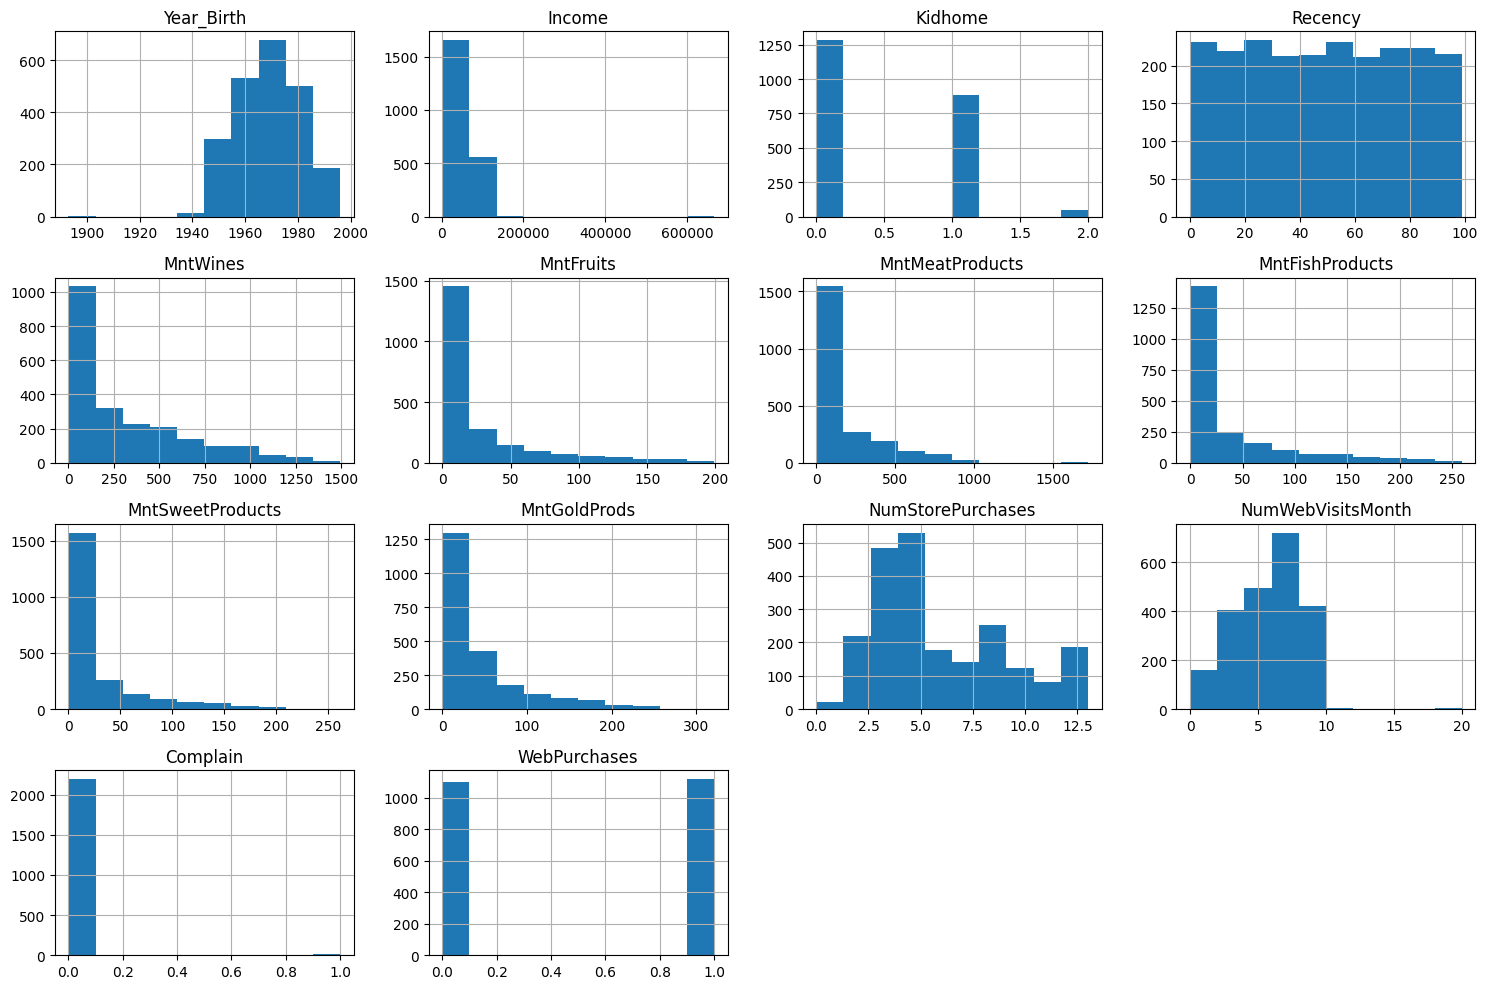

In [18]:
#Gráfico da distribuição das colunas
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

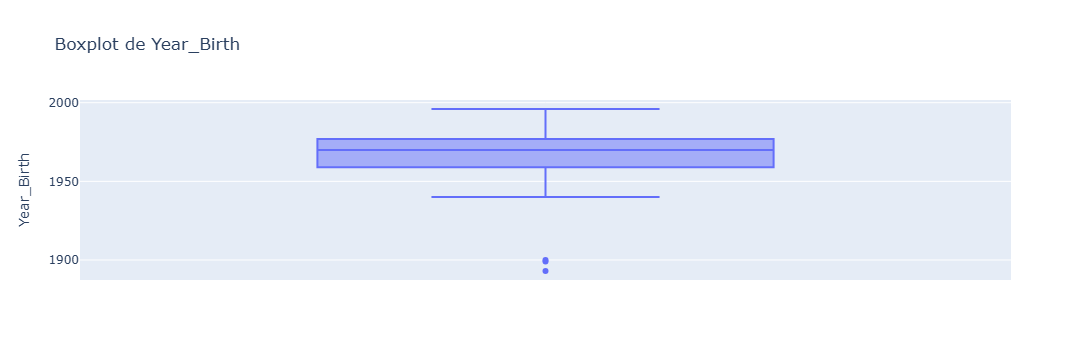

In [57]:
#Verificando coluna Year_Birth
fig = px.box(df, y='Year_Birth', title='Boxplot de Year_Birth')
fig.show()

In [100]:
#Excluindo prováveis erros de entrada
df.drop(df[df["Year_Birth"] < 1901].index, inplace=True)

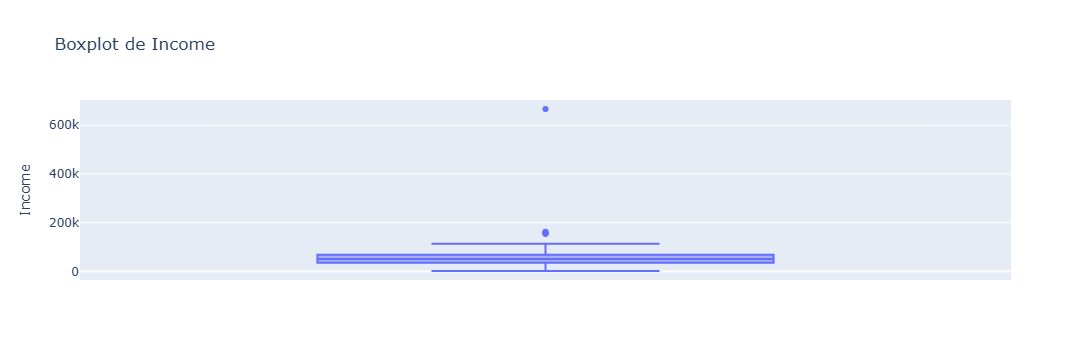

In [59]:
#Verificando coluna de renda 'income'
fig = px.box(df, y='Income', title='Boxplot de Income')
fig.show()

In [60]:
#Cruzamento de variáveis
df.sort_values('Income', ascending=False)[
    ['Income', 'Recency', 'MntFruits', 'MntWines']
].head(10)

,Income,Recency,MntFruits,MntWines
2233,666666.0,23,14,9
617,162397.0,31,1,85
687,160803.0,21,16,55
1300,157733.0,37,1,39
164,157243.0,98,2,20
1653,157146.0,13,0,1
2132,156924.0,85,1,2
655,153924.0,81,1,1
1898,113734.0,9,2,6
646,105471.0,36,181,1009


Embora existam rendas altas consideradas outliers naturais da distribuição, o valor "666666.0" da coluna "Income" parece ser um erro de entrada, portanto foi escolhido fazer a remoção deste. 

In [101]:
#Removendo valor da coluna
df = df[df["Income"] != 666666.0]

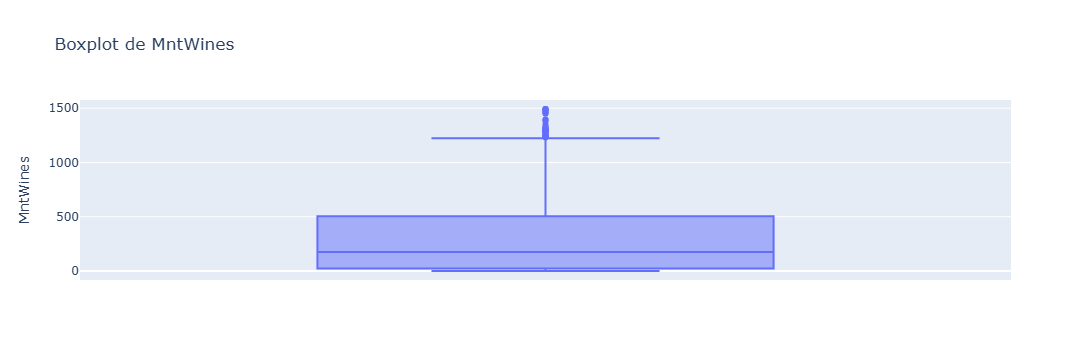

In [62]:
#Verificação da coluna MntWines
fig = px.box(df, y='MntWines', title='Boxplot de MntWines')
fig.show()

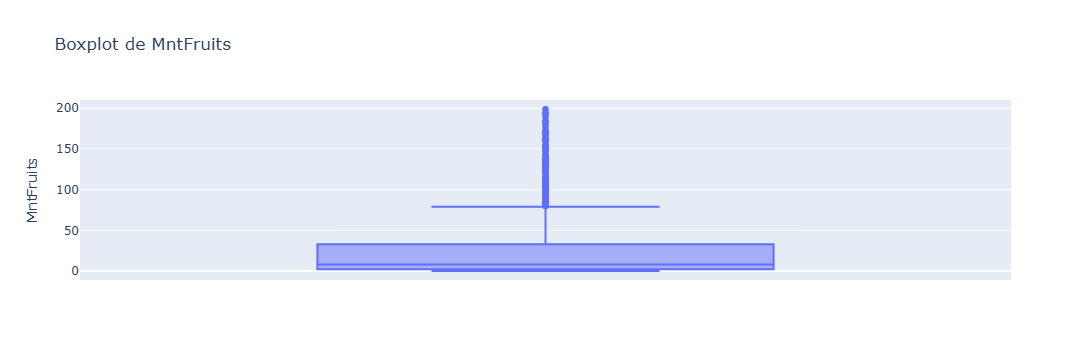

In [68]:
fig = px.box(df, y='MntFruits', title='Boxplot de MntFruits')
fig.show()  

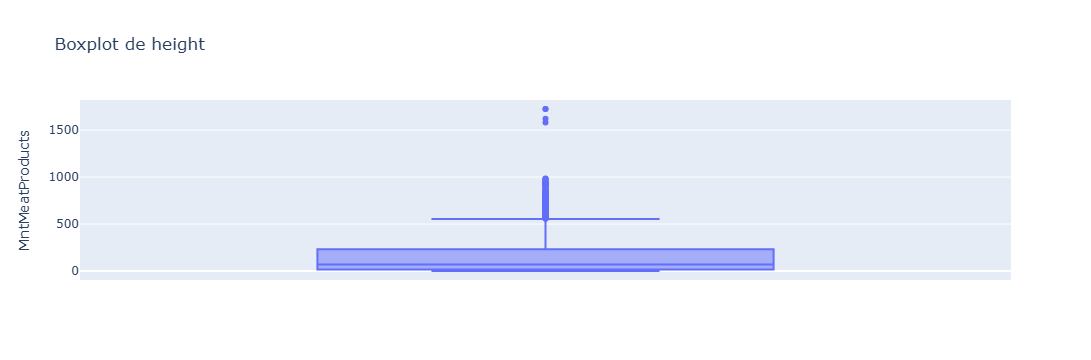

In [26]:
fig = px.box(df, y='MntMeatProducts', title='Boxplot de MntMeatProducts')
fig.show() 

In [14]:
#Cruzamento de variáveis
df.sort_values('MntMeatProducts', ascending=False)[
    ['MntMeatProducts', 'Recency', 'MntFruits', 'MntWines']
].head(10)

,MntMeatProducts,Recency,MntFruits,MntWines
21,1725,42,1,1
1653,1725,13,0,1
687,1622,21,16,55
164,1582,98,2,20
1358,984,85,129,557
1808,981,2,51,292
456,974,44,24,606
2109,968,89,59,830
1031,961,58,172,576
126,951,37,133,450


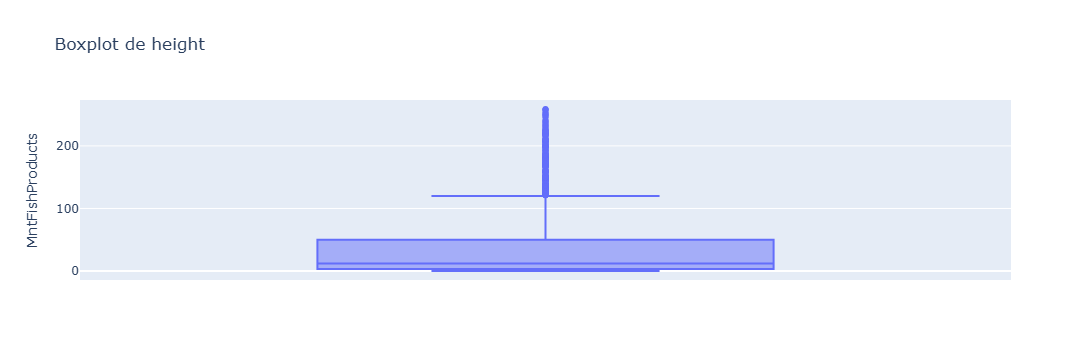

In [27]:
fig = px.box(df, y='MntFishProducts', title='Boxplot de MntFishProducts')
fig.show() 

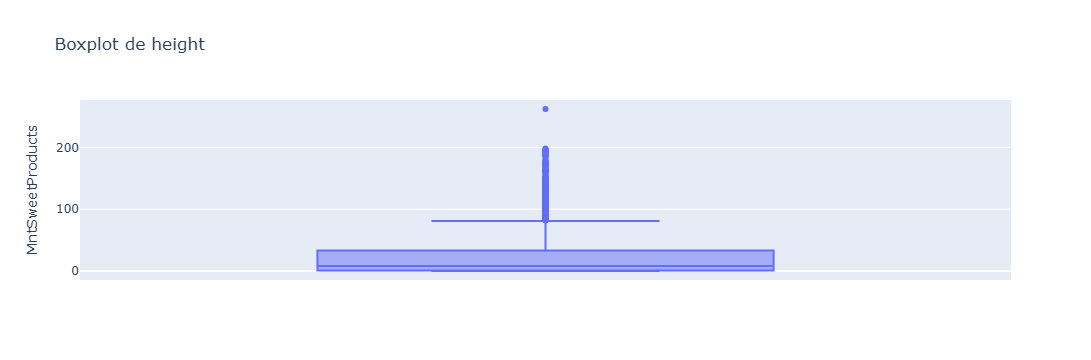

In [29]:
fig = px.box(df, y='MntSweetProducts', title='Boxplot de MntSweetProducts')
fig.show()

In [7]:
#Cruzamento de variáveis
df.sort_values('MntSweetProducts', ascending=False)[
    ['MntSweetProducts', 'Recency', 'MntFruits', 'MntWines']
].head(10)

,MntSweetProducts,Recency,MntFruits,MntWines
1898,262,9,2,6
634,198,12,22,514
1513,197,1,42,423
1671,196,66,107,446
1253,195,92,27,133
1484,194,50,97,378
456,194,44,24,606
2012,194,79,43,908
470,192,47,76,563
2096,192,47,132,240


In [102]:
#Removendo valor da coluna
df = df[df["MntSweetProducts"] != 262]

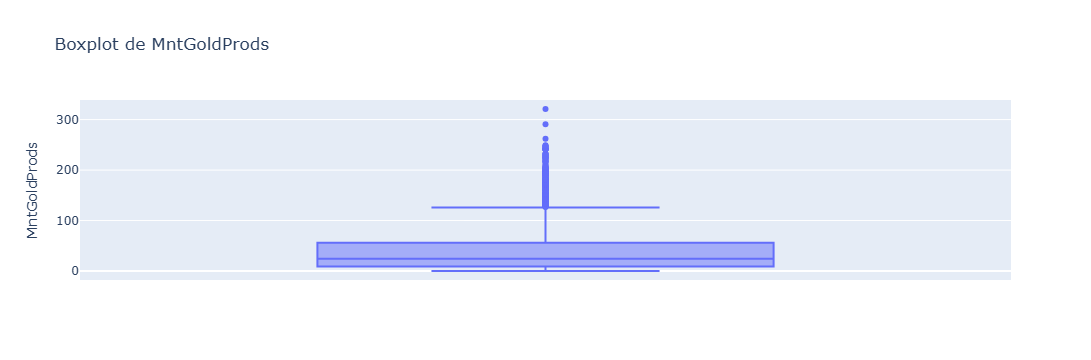

In [36]:
#Verificando coluna de renda 'income'
fig = px.box(df, y='MntGoldProds', title='Boxplot de MntGoldProds')
fig.show()

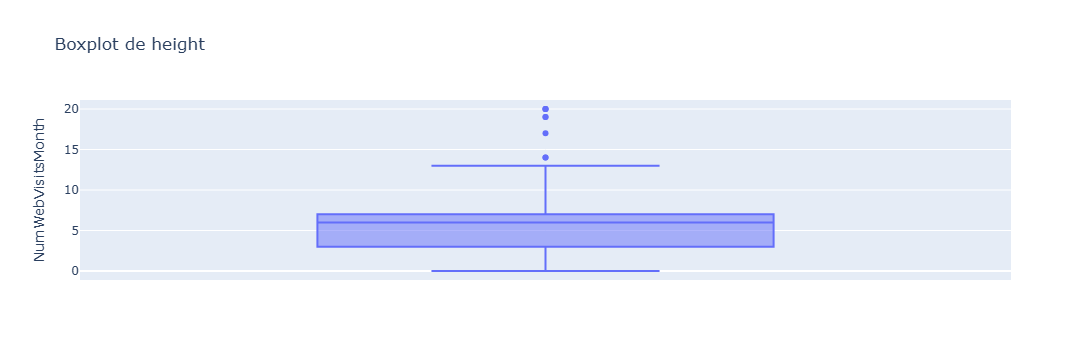

In [31]:
fig = px.box(df, y='NumWebVisitsMonth', title='Boxplot de height')
fig.show()

A maioria das colunas possuem Outliers, algumas com valores que aparentam ser erros de entrada como Year_Birth, e Income, portanto nessas casos foi optado fazer a remoção, porém algumas delas ainda permaneceram com valores extremos (que pareciam ser dados reias, apenas raros), nesses foi escolhido fazer métodos de diminuição de impacto para aplicar ao modelo como transformação logarítmica para as variáveis monetárias tais como Income, MntWines, MntSweetProducts etc. Alguma variáveis possuem poucos valores e aparentam ser dados reias como NumWebVisitsMonth, como é um dado de acesso e com valores baixos foi optado por não mexer nesses dados. 

In [103]:
#Verificando balanceamento da Target
df['WebPurchases'].value_counts(normalize=True) * 100

WebPurchases
1    50.474898
0    49.525102
Name: proportion, dtype: float64

Como a Target está com os valores de 1 e 0 bem aproximados, não há necessidade de balanceamento. 

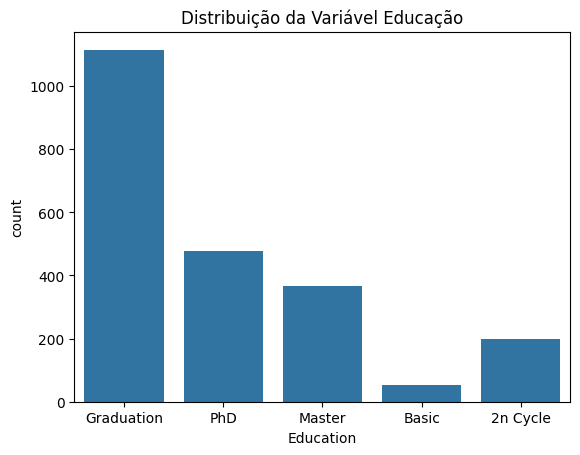

In [91]:
#Verificação da distribuição dos dados de educação
sns.countplot(x='Education', data=df)
plt.title('Distribuição da Variável Educação')
plt.show()

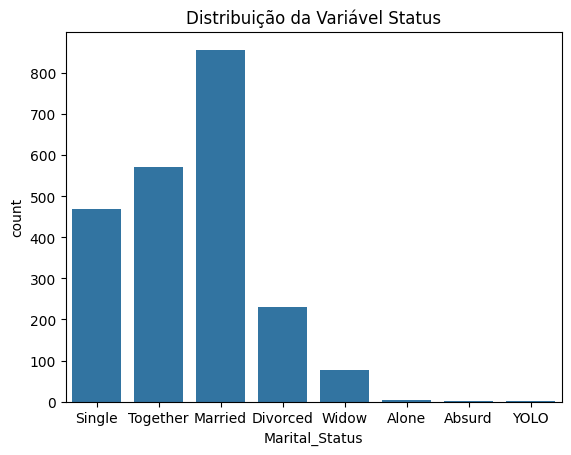

In [92]:
#Verificação da distribuição dos dados de educação
sns.countplot(x='Marital_Status', data=df)
plt.title('Distribuição da Variável Status')
plt.show()

In [17]:
df

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,10.970592,0,58,6.455199,4.488636,6.304449,5.153292,4.488636,4.488636,4,7,0,1
1,1954,Graduation,Single,10.743869,1,38,2.484907,0.693147,1.945910,1.098612,0.693147,1.945910,2,5,0,0
2,1965,Graduation,Together,11.179046,0,26,6.056784,3.912023,4.852030,4.718499,3.091042,3.761200,10,4,0,1
3,1984,Graduation,Together,10.190432,1,26,2.484907,1.609438,3.044522,2.397895,1.386294,1.791759,4,6,0,0
4,1981,PhD,Married,10.973254,1,94,5.159055,3.784190,4.779123,3.850148,3.332205,2.772589,6,5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,11.022295,0,46,6.565265,3.784190,5.209486,3.761200,4.779123,5.513429,4,5,0,1
2236,1946,PhD,Together,11.066873,2,56,6.008813,0.000000,3.433987,0.000000,0.000000,2.197225,5,7,0,1
2237,1981,Graduation,Divorced,10.950491,0,91,6.812345,3.891820,5.384495,3.496508,2.564949,3.218876,13,6,0,0
2238,1956,Master,Together,11.145421,0,8,6.061457,3.433987,5.370638,4.394449,3.433987,4.127134,10,3,0,1


# ETAPA 2:
**Pré-processamento**

**Análise Correlação:** Verifique a correlação entre as váriaveis e análise se há espaço para retirar váriaveis que não te parecem importantes.

**Codificação de Variáveis Categóricas:** Transformar variáveis categóricas em um formato que os modelos de machine learning possam interpretar.


**Separe a base em Y, X e Treino e teste:**: Faça a separação da base.

**Realize a padronização dos dados**: Padronize os dados para garantir eficiência no modelo e eficácia.








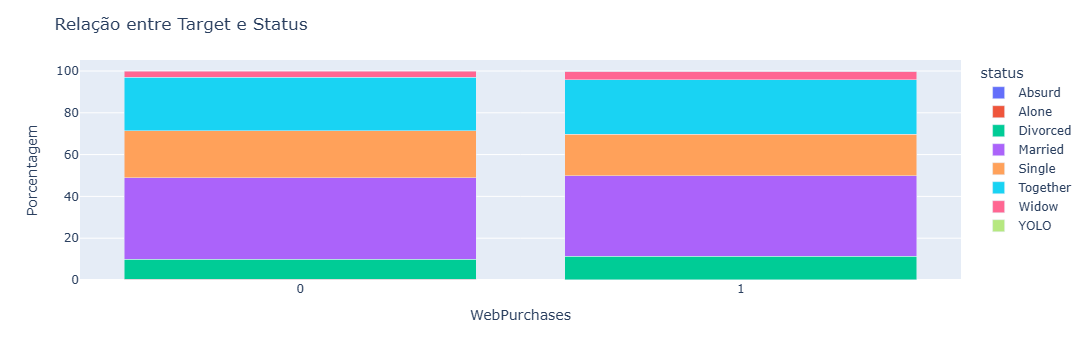

In [37]:
# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['WebPurchases', 'Marital_Status']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('WebPurchases')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='WebPurchases', y='percent', color='Marital_Status', barmode='stack')

fig.update_layout(title='Relação entre Target e Status',
                  yaxis_title='Porcentagem',
                  legend_title='status')
fig.show()

A variável 'Marital_Status' não aparenta explicar muito a Target, visto que os dados estão bem distribuídos.

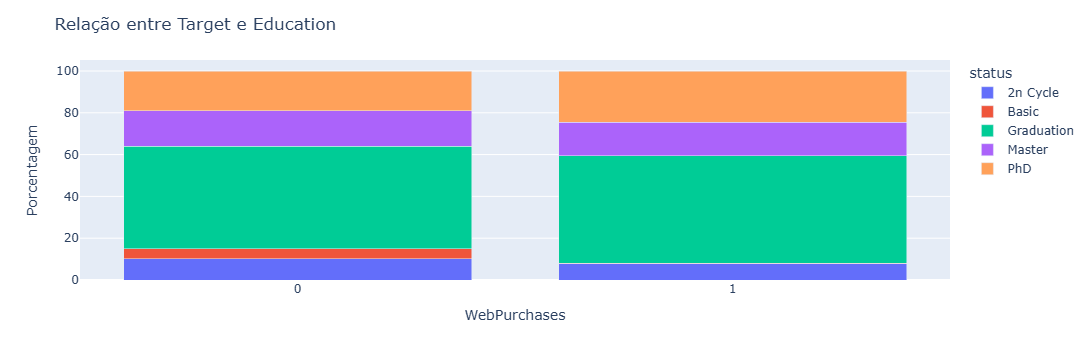

In [38]:
# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['WebPurchases', 'Education']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('WebPurchases')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='WebPurchases', y='percent', color='Education', barmode='stack')

fig.update_layout(title='Relação entre Target e Education',
                  yaxis_title='Porcentagem',
                  legend_title='status')
fig.show()

Pessoas com educação básica não compraram na site. 

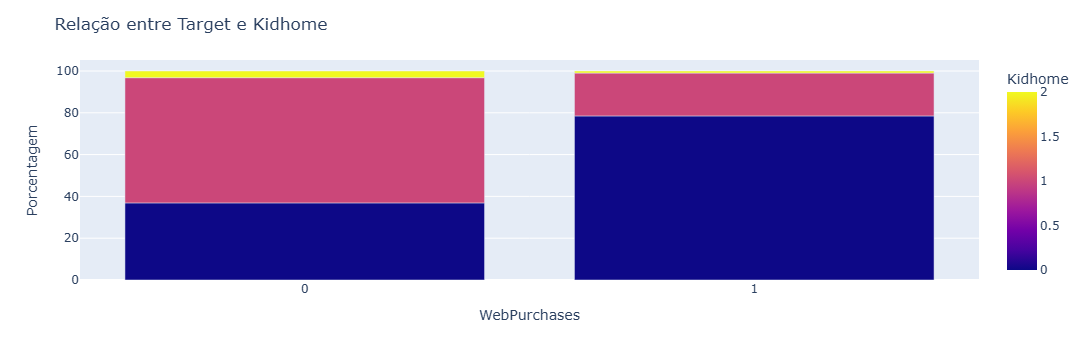

In [39]:
# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['WebPurchases', 'Kidhome']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('WebPurchases')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='WebPurchases', y='percent', color='Kidhome', barmode='stack')

fig.update_layout(title='Relação entre Target e Kidhome',
                  yaxis_title='Porcentagem',
                  legend_title='status')
fig.show()

Pessoas sem filhos tem uma tendência maior a comprarem no site.

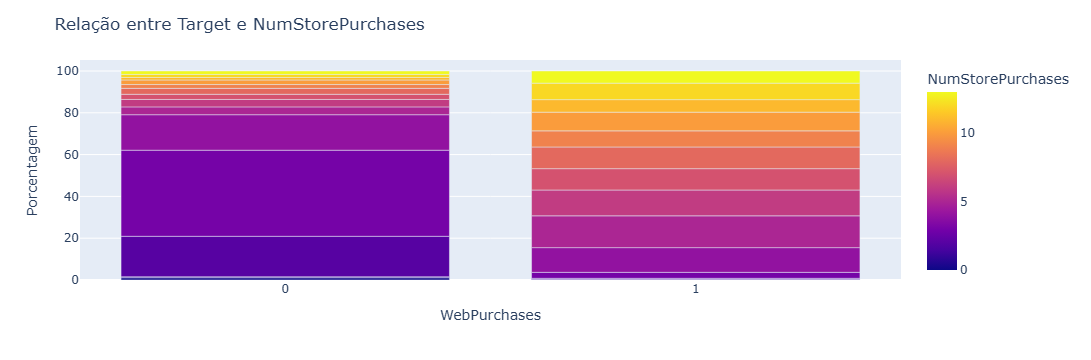

In [43]:
# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['WebPurchases', 'NumStorePurchases']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('WebPurchases')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='WebPurchases', y='percent', color='NumStorePurchases', barmode='stack')

fig.update_layout(title='Relação entre Target e NumStorePurchases',
                  yaxis_title='Porcentagem',
                  legend_title='status')
fig.show()

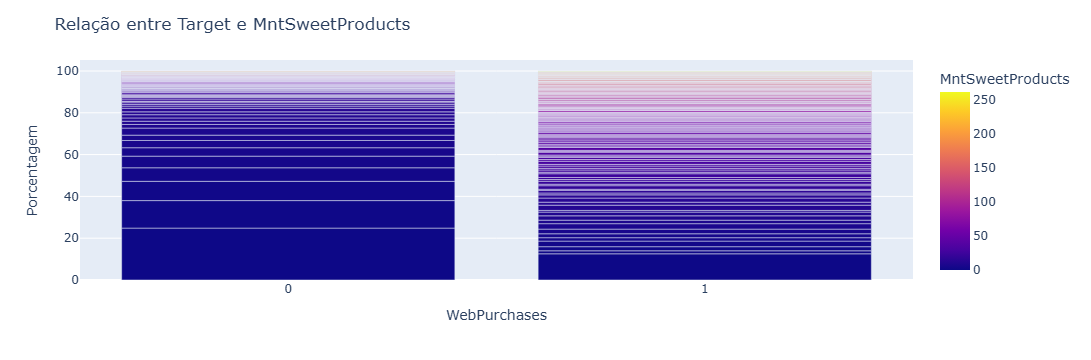

In [45]:
# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['WebPurchases', 'MntSweetProducts']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('WebPurchases')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='WebPurchases', y='percent', color='MntSweetProducts', barmode='stack')

fig.update_layout(title='Relação entre Target e MntSweetProducts',
                  yaxis_title='Porcentagem',
                  legend_title='status')
fig.show()

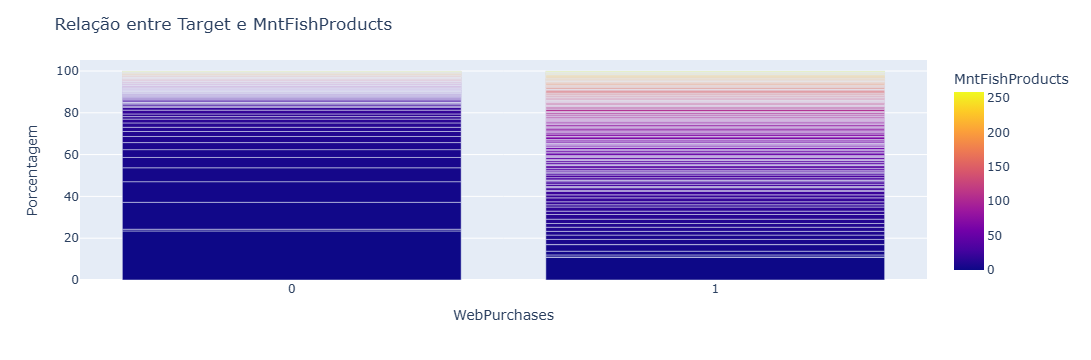

In [46]:
# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['WebPurchases', 'MntFishProducts']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('WebPurchases')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='WebPurchases', y='percent', color='MntFishProducts', barmode='stack')

fig.update_layout(title='Relação entre Target e MntFishProducts',
                  yaxis_title='Porcentagem',
                  legend_title='status')
fig.show()

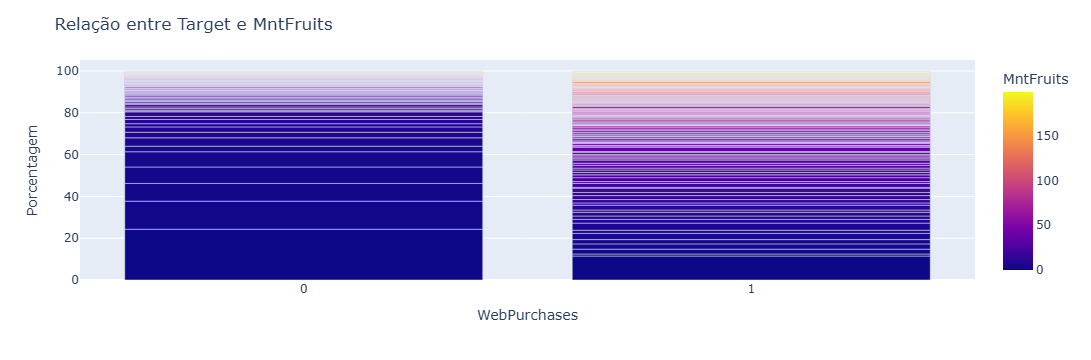

In [48]:
# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['WebPurchases', 'MntFruits']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('WebPurchases')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='WebPurchases', y='percent', color='MntFruits', barmode='stack')

fig.update_layout(title='Relação entre Target e MntFruits',
                  yaxis_title='Porcentagem',
                  legend_title='status')
fig.show()

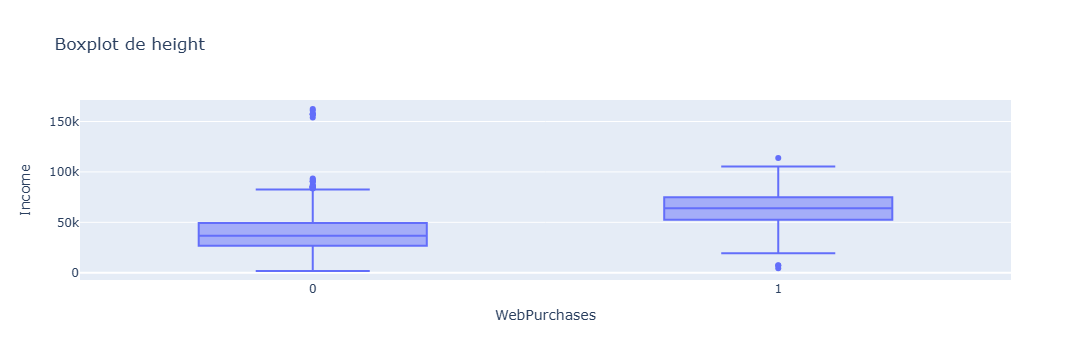

In [51]:
fig = px.box(df, x='WebPurchases', y='Income', title='Boxplot de height')
fig.show()

As pessoas com a média de renda mais alta '63.99k' tendem a comprar mais, mas existem casos raros de rendas mais altas que não compram.

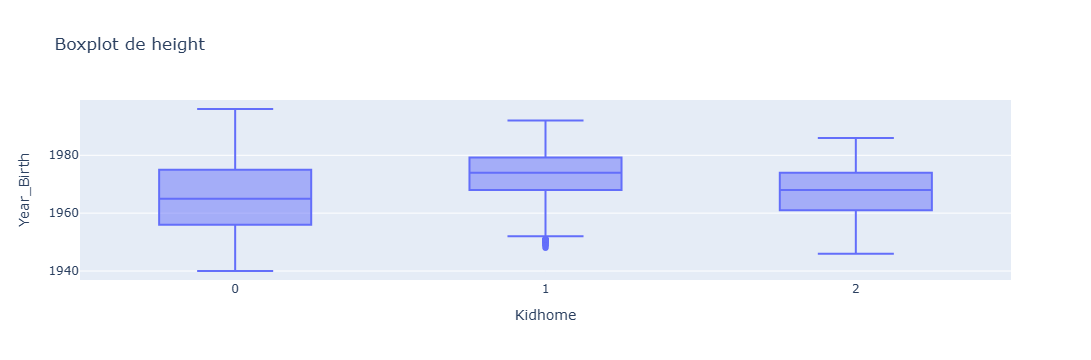

In [54]:
fig = px.box(df, x='Kidhome', y='Year_Birth', title='Boxplot de height')
fig.show()

In [23]:
df

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,10.970592,0,58,6.455199,4.488636,6.304449,5.153292,4.488636,4.488636,4,7,0,1
1,1954,Graduation,Single,10.743869,1,38,2.484907,0.693147,1.945910,1.098612,0.693147,1.945910,2,5,0,0
2,1965,Graduation,Together,11.179046,0,26,6.056784,3.912023,4.852030,4.718499,3.091042,3.761200,10,4,0,1
3,1984,Graduation,Together,10.190432,1,26,2.484907,1.609438,3.044522,2.397895,1.386294,1.791759,4,6,0,0
4,1981,PhD,Married,10.973254,1,94,5.159055,3.784190,4.779123,3.850148,3.332205,2.772589,6,5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,11.022295,0,46,6.565265,3.784190,5.209486,3.761200,4.779123,5.513429,4,5,0,1
2236,1946,PhD,Together,11.066873,2,56,6.008813,0.000000,3.433987,0.000000,0.000000,2.197225,5,7,0,1
2237,1981,Graduation,Divorced,10.950491,0,91,6.812345,3.891820,5.384495,3.496508,2.564949,3.218876,13,6,0,0
2238,1956,Master,Together,11.145421,0,8,6.061457,3.433987,5.370638,4.394449,3.433987,4.127134,10,3,0,1


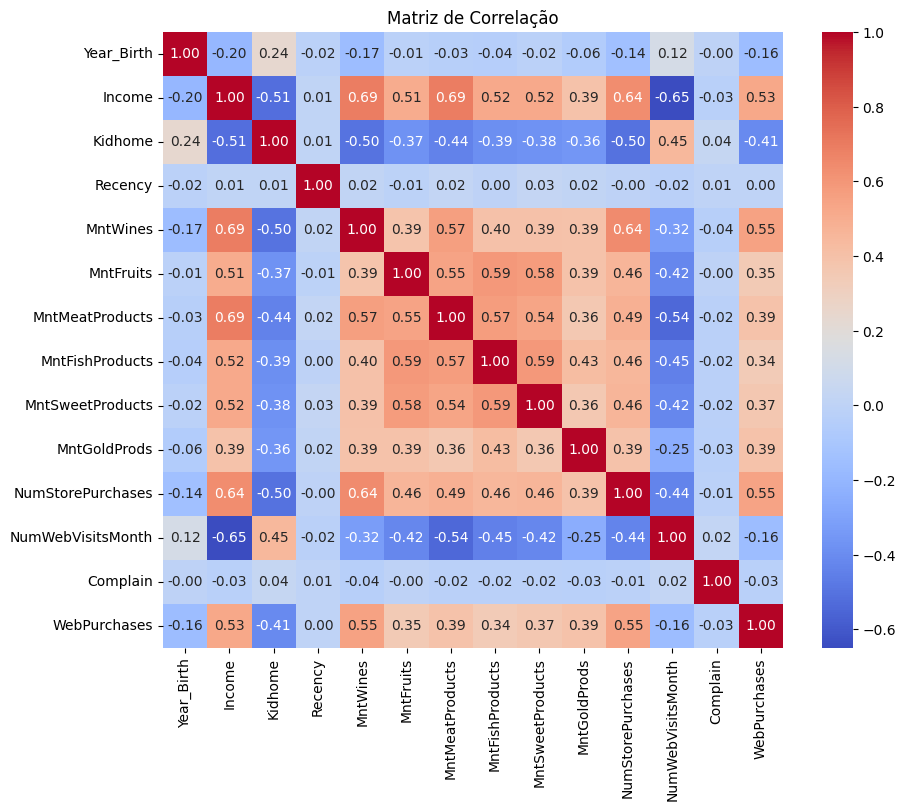

In [104]:
#Análise de Correlação
corr_matriz = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matriz, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

In [105]:
# Codificação de variáveis categóricas
df = pd.get_dummies(
    df,
    columns=['Education', 'Marital_Status'],
    drop_first=True
)

In [106]:
pd.set_option('display.max_columns', None)
print(df)

      Year_Birth   Income  Kidhome  Recency  MntWines  MntFruits  \
0           1957  58138.0        0       58       635         88   
1           1954  46344.0        1       38        11          1   
2           1965  71613.0        0       26       426         49   
3           1984  26646.0        1       26        11          4   
4           1981  58293.0        1       94       173         43   
...          ...      ...      ...      ...       ...        ...   
2235        1967  61223.0        0       46       709         43   
2236        1946  64014.0        2       56       406          0   
2237        1981  56981.0        0       91       908         48   
2238        1956  69245.0        0        8       428         30   
2239        1954  52869.0        1       40        84          3   

      MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  \
0                 546              172                88            88   
1                   6              

In [122]:
#Separando X e Y
X = df.drop('WebPurchases', axis=1)
Y = df['WebPurchases']

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [124]:
#Padronização das variáveis
# Inicializar StandardScaler
sc = StandardScaler()

# Ajustando e transformando os dados de treino
X_train = sc.fit_transform(X_train)

# Transformando os dados de teste usando os parâmetros aprendidos dos dados de treino
X_test = sc.transform(X_test)

In [125]:
y_train

1714    0
781     0
945     1
1736    1
452     0
       ..
1658    1
1111    1
1146    0
1310    1
876     1
Name: WebPurchases, Length: 1658, dtype: int64

# ETAPA 3:

**Modelagem**

Escolha ao menos 2 técnicas de machine learning e rode 2 modelos, afim de identificar qual tem o melhor resultado para essa base. Lembrando que estamos lidando com uma classificação binária.

**RANDOM FOREST**

In [111]:
#Instanciando Random Forest para modelagem
modelo = RandomForestClassifier(n_estimators=100, random_state=42)

In [112]:
#Treinando o modelo
modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [113]:
#Validação do modelo
from sklearn.metrics import accuracy_score
y_predito = modelo.predict(X_test)
print(accuracy_score(y_test, y_predito))

0.8842676311030742


In [115]:
#Relatório de modelo com algumas com Mnt Wines
relatorio = classification_report(y_test, y_predito)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       277
           1       0.87      0.91      0.89       276

    accuracy                           0.88       553
   macro avg       0.89      0.88      0.88       553
weighted avg       0.89      0.88      0.88       553



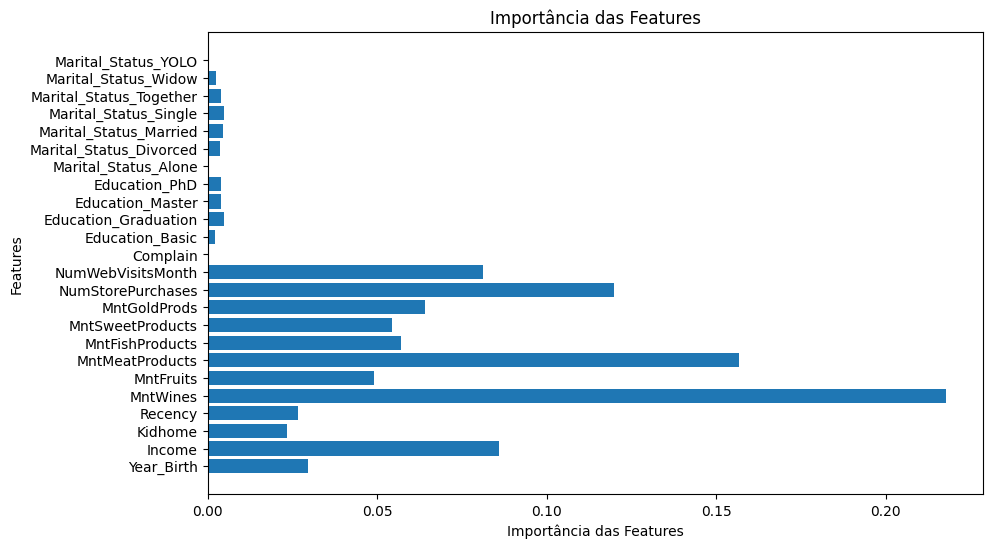

In [116]:
#Melhorando o modelo com Feature importance
# Obtendo a importância das características do modelo
features_importantes = modelo.feature_importances_

# Obtendo os nomes das características
nomes_features = X.columns

# Criando o gráfico
plt.figure(figsize=(10, 6))
plt.barh(nomes_features, features_importantes)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features')
plt.show()

In [117]:
#Selecionando as melhores features encontradas pelo modelo
melhores_features = [
    'MntWines',
    'MntMeatProducts',
    'NumStorePurchases',
    'Income',
    'NumWebVisitsMonth'   
]

X_novo = X[melhores_features]

In [118]:
#Separando treino e teste com as novas features
X_train, X_test, y_train, y_test = train_test_split(
    X_novo,
    Y,
    test_size=0.2,
    random_state=42
)

In [119]:
#Instância do modelo com melhores features e treinamento
rf_novo = RandomForestClassifier(
    random_state=42
)

rf_novo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [120]:
#Fazendo validação com dados de teste
y_pred = rf_novo.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.909706546275395


**ÁRVORE DE DECISÃO**

In [135]:
#Treinando o dataset com outro modelo 
arvore = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
arvore.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [136]:
#Previsão e validação
previsao = arvore.predict(X_test)
acuracia = accuracy_score(y_test, previsao)
print("Acurácia:", acuracia)

Acurácia: 0.8679927667269439


In [140]:
matriz_confusao = confusion_matrix(y_test, previsao)
print(matriz_confusao)

[[239  38]
 [ 35 241]]


In [141]:
#Árvore de decisão relatório
relatorio = classification_report(y_test, previsao)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       277
           1       0.86      0.87      0.87       276

    accuracy                           0.87       553
   macro avg       0.87      0.87      0.87       553
weighted avg       0.87      0.87      0.87       553



In [143]:
features_importantes = arvore.feature_importances_
print(features_importantes)

[0.02177214 0.05110329 0.         0.02556033 0.58870486 0.01610634
 0.08576982 0.027058   0.01833519 0.02775012 0.00745121 0.09681742
 0.         0.         0.01065562 0.         0.         0.
 0.00242425 0.00703783 0.00736071 0.00120649 0.00488641 0.        ]


In [144]:
nomes_features = X.columns

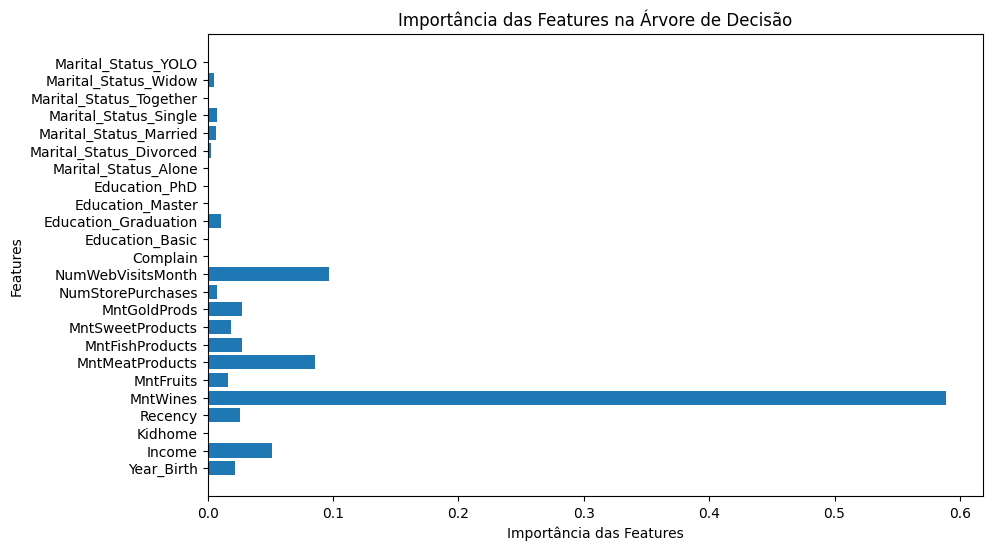

In [145]:
plt.figure(figsize=(10, 6))
plt.barh(nomes_features, features_importantes)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

In [149]:
melhor_features = [
    'MntWines',
    'MntMeatProducts',
    'Income',
    'NumWebVisitsMonth'   
]

X_arvore_novo = X[melhor_features]

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_arvore_novo,
    Y,
    test_size=0.2,
    random_state=42
)

In [151]:
from sklearn.ensemble import RandomForestClassifier

arvore_novo = RandomForestClassifier(
    random_state=42
)

arvore_novo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [152]:
from sklearn.metrics import accuracy_score

y_prediz = arvore_novo.predict(X_test)

print(accuracy_score(y_test, y_prediz))

0.9187358916478555


# ETAPA 4:

**Avaliação**

Avalie os resultados encontrados nos dois modelos e identifique qual te pareceu realizar melhor as previsões.

Utilize além das métricas padrões a matriz de confusão.

In [121]:
#Avaliação do modelo Random Forest com feature importance
relatorio = classification_report(y_test, y_pred)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       229
           1       0.90      0.92      0.91       214

    accuracy                           0.91       443
   macro avg       0.91      0.91      0.91       443
weighted avg       0.91      0.91      0.91       443



O modelo incialmente com todos os dados teve uma acurácia geral de 0.88, algumas métricas como precisão para a classe '1' como 0.87, portanto foi aplicado o 'Feature importance' e houve melhora geral para 0.91.

In [153]:
#Avaliação de Árvore de decisão com feature importance
relatorio = classification_report(y_test, y_prediz)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       229
           1       0.90      0.93      0.92       214

    accuracy                           0.92       443
   macro avg       0.92      0.92      0.92       443
weighted avg       0.92      0.92      0.92       443



O modelo de árvore de decisão se mostrou melhor para os dados apresentados, pois melhorou a acurácia geral para 0.92, e só houve melhora nas outras métricas gerais como precisão, recall e f1-score. 

Foram escolhidos dois modelos para treinar os dados da base. Sendo eles o Random Forest e a Árvore de Decisão. Inicialmente o Random Forest apresentou uma acurácia geral de 0.8842676311030742, então foi escolhido fazer o feature importance, e houve uma melhoria considerável na acurácia 0.91. O segundo modelo treinado como já mencionado foi a Árvore de Decisão, que inicialmente uma acurácia de 0.8679927667269439 (sendo menor que a do Random Forest), porém ao selecionar 